In [2]:
import pandas as pd
import zipfile
import io
from google.colab import files

print("Please upload the 'archive.zip' file again.")
uploaded = files.upload()

# Get the name and content of the uploaded zip file
zip_filename = list(uploaded.keys())[0]
zip_content = uploaded[zip_filename]

# Save the zip content to a temporary file
with open(zip_filename, 'wb') as f:
    f.write(zip_content)

# Extract the contents of the zip file
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    extracted_files = zip_ref.namelist()
    excel_file_name = None
    for f_name in extracted_files:
        if f_name.endswith('.xlsx'):
            excel_file_name = f_name
            break
    if excel_file_name:
        # Ensure the file is extracted to the current working directory
        zip_ref.extract(excel_file_name)
        # Read the Excel file into a DataFrame
        df = pd.read_excel(excel_file_name)
    else:
        print("No .xlsx file found in the zip archive. Please re-upload the correct zip file.")

# Calculate the 'revenue' column
df['revenue'] = df['unit_price'] * df['transaction_qty']

# Calculate the 'hour' column
df['hour'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour

print("DataFrame 'df' and its 'revenue' and 'hour' columns have been successfully re-initialized.")
print(df.head())

Please upload the 'archive.zip' file again.


Saving archive.zip to archive.zip
DataFrame 'df' and its 'revenue' and 'hour' columns have been successfully re-initialized.
   transaction_id transaction_date transaction_time  transaction_qty  \
0               1       2023-01-01         07:06:11                2   
1               2       2023-01-01         07:08:56                2   
2               3       2023-01-01         07:14:04                2   
3               4       2023-01-01         07:20:24                1   
4               5       2023-01-01         07:22:41                2   

   store_id   store_location  product_id  unit_price    product_category  \
0         5  Lower Manhattan          32         3.0              Coffee   
1         5  Lower Manhattan          57         3.1                 Tea   
2         5  Lower Manhattan          59         4.5  Drinking Chocolate   
3         5  Lower Manhattan          22         2.0              Coffee   
4         5  Lower Manhattan          57         3.1          

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [4]:
import zipfile
import io

# Get the name and content of the uploaded zip file
zip_filename = list(uploaded.keys())[0]
zip_content = uploaded[zip_filename]

# Save the zip content to a temporary file
with open(zip_filename, 'wb') as f:
    f.write(zip_content)

# Extract the contents of the zip file
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    # Assuming there's only one file or you know the name of the Excel file
    # In this case, it's 'Coffee Shop Sales.xlsx'
    extracted_files = zip_ref.namelist()
    excel_file_name = None
    for f_name in extracted_files:
        if f_name.endswith('.xlsx'):
            excel_file_name = f_name
            break
    if excel_file_name:
        zip_ref.extract(excel_file_name)
        # Read the Excel file into a DataFrame
        df = pd.read_excel(excel_file_name)
        print("Rows and Col:", df.shape)
        print(df.head())
    else:
        print("No .xlsx file found in the zip archive.")

Rows and Col: (149116, 11)
   transaction_id transaction_date transaction_time  transaction_qty  \
0               1       2023-01-01         07:06:11                2   
1               2       2023-01-01         07:08:56                2   
2               3       2023-01-01         07:14:04                2   
3               4       2023-01-01         07:20:24                1   
4               5       2023-01-01         07:22:41                2   

   store_id   store_location  product_id  unit_price    product_category  \
0         5  Lower Manhattan          32         3.0              Coffee   
1         5  Lower Manhattan          57         3.1                 Tea   
2         5  Lower Manhattan          59         4.5  Drinking Chocolate   
3         5  Lower Manhattan          22         2.0              Coffee   
4         5  Lower Manhattan          57         3.1                 Tea   

            product_type               product_detail  
0  Gourmet brewed coffee   

In [5]:
df['revenue'] = df['unit_price'] * df['transaction_qty']
print("Total Revenue:  $", round(df['revenue'].sum(), 2))

Total Revenue:  $ 698812.33


### Re-initializing DataFrame `df` and its derived columns

It seems the kernel was restarted, causing the `df` DataFrame to be undefined. This cell will re-load the data and calculate the `revenue` and `hour` columns, ensuring everything is set up for generating the report.

In [7]:
from google.colab import drive
# If 'credential propagation was unsuccessful' error occurs, try re-running this cell.
# If it persists, check your internet connection or restart the Colab runtime.
drive.mount('/content/drive')

Mounted at /content/drive


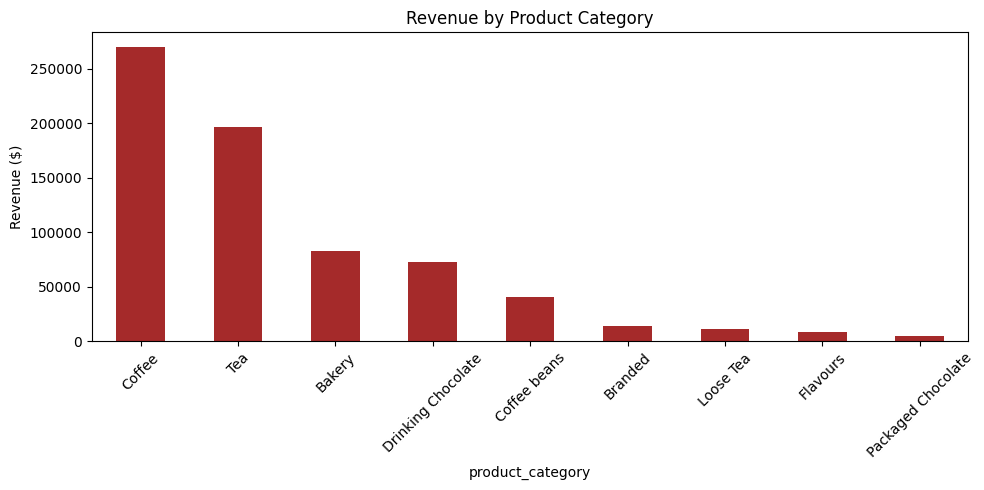

In [8]:
category_sales = df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar', color='brown', figsize=(10,5))
plt.title('Revenue by Product Category')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

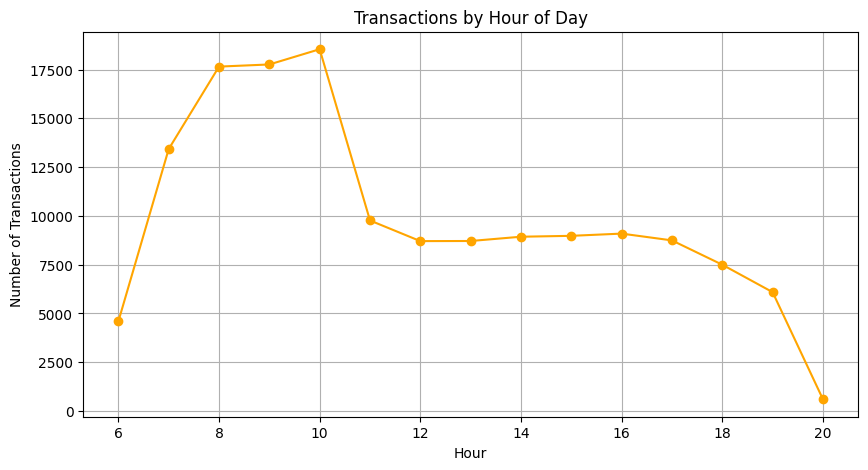

In [9]:
df['hour'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour

df.groupby('hour')['transaction_id'].count().plot(kind='line', marker='o', color='orange', figsize=(10,5))
plt.title('Transactions by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.show()

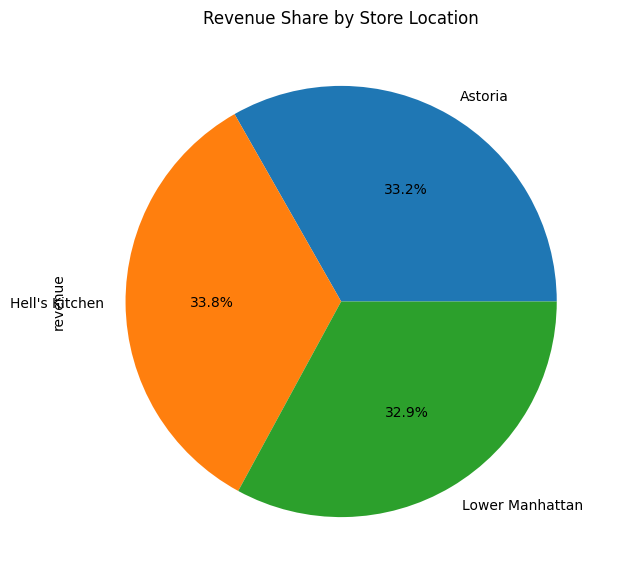

In [10]:
df.groupby('store_location')['revenue'].sum().plot(kind='pie', autopct='%1.1f%%', figsize=(7,7))
plt.title('Revenue Share by Store Location')
plt.show()

In [11]:
# Install karo pehle
!pip install fpdf2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 15.1 MB/s eta 0:00:00


In [13]:
from fpdf import FPDF, XPos, YPos
import matplotlib.pyplot as plt

# Graphs save karo pehle
# Graph 1 - Category
category_sales = df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)
category_sales.plot(kind='bar', color='brown', figsize=(10,5))
plt.title('Revenue by Product Category')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('category.png')
plt.close()

# Graph 2 - Hours
df.groupby('hour')['transaction_id'].count().plot(kind='line', marker='o', color='orange', figsize=(10,5))
plt.title('Transactions by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Transactions')
plt.grid(True)
plt.tight_layout()
plt.savefig('hours.png')
plt.close()

# Graph 3 - Location
df.groupby('store_location')['revenue'].sum().plot(kind='pie', autopct='%1.1f%%', figsize=(7,7))
plt.title('Revenue Share by Store Location')
plt.tight_layout()
plt.savefig('location.png')
plt.close()

# PDF banao
pdf = FPDF()
pdf.set_auto_page_break(auto=True, margin=15)

# Page 1 - Title
pdf.add_page()
pdf.set_font('Helvetica', 'B', 24)
pdf.cell(0, 20, 'Coffee Shop Business Report', new_x=XPos.LMARGIN, new_y=YPos.NEXT, align='C')
pdf.set_font('Helvetica', '', 14)
pdf.cell(0, 10, 'Data Analysis - 149,116 Transactions', new_x=XPos.LMARGIN, new_y=YPos.NEXT, align='C')
pdf.ln(10)

pdf.set_font('Helvetica', 'B', 16)
pdf.cell(0, 10, 'Key Business Insights:', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.set_font('Helvetica', '', 13)
pdf.multi_cell(0, 10, '1. Coffee is the top revenue category at ~$270,000 (36% of total)', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.multi_cell(0, 10, '2. Tea is strong second at ~$197,000', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.multi_cell(0, 10, '3. Peak hours are 8AM-10AM - highest staff needed', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.multi_cell(0, 10, '4. All 3 store locations perform equally (~33% each)', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.multi_cell(0, 10, '5. Packaged Chocolate has lowest revenue - consider discontinuing', new_x=XPos.LMARGIN, new_y=YPos.NEXT)

# Page 2 - Graphs
pdf.add_page()
pdf.set_font('Helvetica', 'B', 16)
pdf.cell(0, 10, 'Revenue by Product Category', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.image('category.png', x=10, w=190)

pdf.add_page()
pdf.set_font('Helvetica', 'B', 16)
pdf.cell(0, 10, 'Peak Hours Analysis', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.image('hours.png', x=10, w=190)

pdf.add_page()
pdf.set_font('Helvetica', 'B', 16)
pdf.cell(0, 10, 'Revenue Share by Store Location', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.image('location.png', x=40, w=130)

# Save
pdf.output('coffee_report.pdf')
print("✅ Report ban gayi! Left panel mein coffee_report.pdf dekho")

✅ Report ban gayi! Left panel mein coffee_report.pdf dekho
